# Healthcare Risk Stratification and Outcome Prediction

This project analyzes patient demographics, diagnoses, laboratory results, treatment costs, and clinical outcomes to explore healthcare risk patterns and develop a machine learning model for predicting adverse patient outcomes.

### Workflow
- Data Cleaning and Integration
- Exploratory Data Analysis
- Feature Engineering
- Machine Learning
- Model Evaluation and Comparison
- Final Model Selection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load datasets
patients = pd.read_csv('patients.csv')
diagnoses = pd.read_csv('diagnoses.csv')
outcomes = pd.read_csv('outcomes.csv')
labs = pd.read_csv('labs.csv')

print("Patients:", patients.shape)
print("Diagnoses:", diagnoses.shape)
print("Outcomes:", outcomes.shape)
print("Labs:", labs.shape)

Patients: (200, 12)
Diagnoses: (10, 2)
Outcomes: (3, 2)
Labs: (200, 5)


 1. Data Cleaning and Preparation

The patient dataset is cleaned by retaining the original patient-level variables required for analysis and modeling. Dates are converted to datetime format and basic data quality checks are performed.


In [2]:
# Keep only the original patient-level columns
patients_clean = patients[[
    'PatientID',
    'Name',
    'Age',
    'Gender',
    'DiagnosisID',
    'AdmissionDate',
    'DischargeDate',
    'OutcomeID',
    'TreatmentCost'
]].copy()

# Convert dates
patients_clean['AdmissionDate'] = pd.to_datetime(
    patients_clean['AdmissionDate'],
    dayfirst=True
)

patients_clean['DischargeDate'] = pd.to_datetime(
    patients_clean['DischargeDate'],
    dayfirst=True
)

# Basic data quality checks
print("Shape:", patients_clean.shape)
print("Duplicate Patient IDs:", patients_clean['PatientID'].duplicated().sum())
print("\nMissing Values:")
print(patients_clean.isnull().sum())

patients_clean.head()

Shape: (200, 9)
Duplicate Patient IDs: 0

Missing Values:
PatientID        0
Name             0
Age              0
Gender           0
DiagnosisID      0
AdmissionDate    0
DischargeDate    0
OutcomeID        0
TreatmentCost    0
dtype: int64


,PatientID,Name,Age,Gender,DiagnosisID,AdmissionDate,DischargeDate,OutcomeID,TreatmentCost
0,1,Edward Montes,68,M,2,2025-03-22,2025-04-04,1,4443
1,2,Jessica Zimmerman,81,M,2,2025-03-31,2025-04-02,2,4265
2,3,Gina Alexander,58,M,6,2025-01-08,2025-03-13,1,4188
3,4,Lori Green,44,F,3,2025-04-03,2025-04-05,1,9783
4,5,Jack Logan,72,F,9,2025-06-03,2025-06-04,1,5005


 2. Data Integration

Patient records are enriched with diagnosis and outcome information by merging the corresponding reference tables using their unique IDs.

In [3]:
# Merge diagnosis information
data = patients_clean.merge(
    diagnoses,
    on='DiagnosisID',
    how='left'
)

# Merge outcome information
data = data.merge(
    outcomes,
    on='OutcomeID',
    how='left'
)

# Verify merged dataset
print("Merged Shape:", data.shape)
print("\nColumns:")
print(data.columns.tolist())

data.head()

Merged Shape: (200, 11)

Columns:
['PatientID', 'Name', 'Age', 'Gender', 'DiagnosisID', 'AdmissionDate', 'DischargeDate', 'OutcomeID', 'TreatmentCost', 'DiagnosisName', 'OutcomeName']


,PatientID,Name,Age,Gender,DiagnosisID,AdmissionDate,DischargeDate,OutcomeID,TreatmentCost,DiagnosisName,OutcomeName
0,1,Edward Montes,68,M,2,2025-03-22,2025-04-04,1,4443,Diabetes,Recovered
1,2,Jessica Zimmerman,81,M,2,2025-03-31,2025-04-02,2,4265,Diabetes,Complicated
2,3,Gina Alexander,58,M,6,2025-01-08,2025-03-13,1,4188,COPD,Recovered
3,4,Lori Green,44,F,3,2025-04-03,2025-04-05,1,9783,Heart Disease,Recovered
4,5,Jack Logan,72,F,9,2025-06-03,2025-06-04,1,5005,Kidney Disease,Recovered


## 3. Laboratory Feature Engineering

Laboratory results are transformed from long format into patient-level features. Each laboratory test becomes a separate feature, allowing the model to use individual test results rather than only a combined abnormal-lab count.

In [4]:
# Convert lab results into patient-level features
lab_features = labs.pivot_table(
    index='PatientID',
    columns='TestName',
    values='Result',
    aggfunc='mean'
).reset_index()

# Remove the column-axis label created by pivot_table
lab_features.columns.name = None

print("Lab Feature Shape:", lab_features.shape)
print("\nLab Features:")
print(lab_features.columns.tolist())

lab_features.head()

Lab Feature Shape: (131, 7)

Lab Features:
['PatientID', 'Blood Pressure', 'Blood Sugar', 'Cholesterol', 'Creatinine', 'Hemoglobin', 'Vitamin D']


,PatientID,Blood Pressure,Blood Sugar,Cholesterol,Creatinine,Hemoglobin,Vitamin D
0,2,NaN,245.0,NaN,NaN,NaN,NaN
1,4,NaN,NaN,NaN,NaN,NaN,162.8
2,5,NaN,NaN,67.0,NaN,NaN,NaN
3,7,133.8,NaN,NaN,NaN,90.2,296.9
4,8,NaN,NaN,NaN,NaN,89.9,NaN


 4. Patient-Level Feature Dataset

The engineered laboratory features are merged with the patient dataset. A left join is used to retain all patients, including those without recorded laboratory results.

In [5]:
# Merge laboratory features with patient data
data = data.merge(
    lab_features,
    on='PatientID',
    how='left'
)

# Create Length of Stay
data['LengthOfStay'] = (
    data['DischargeDate'] - data['AdmissionDate']
).dt.days

print("Final Dataset Shape:", data.shape)

print("\nMissing Lab Values:")
print(
    data[
        ['Blood Pressure', 'Blood Sugar', 'Cholesterol',
         'Creatinine', 'Hemoglobin', 'Vitamin D']
    ].isnull().sum()
)

data.head()

Final Dataset Shape: (200, 18)

Missing Lab Values:
Blood Pressure    167
Blood Sugar       171
Cholesterol       167
Creatinine        175
Hemoglobin        175
Vitamin D         160
dtype: int64


,PatientID,Name,Age,Gender,DiagnosisID,AdmissionDate,DischargeDate,OutcomeID,TreatmentCost,DiagnosisName,OutcomeName,Blood Pressure,Blood Sugar,Cholesterol,Creatinine,Hemoglobin,Vitamin D,LengthOfStay
0,1,Edward Montes,68,M,2,2025-03-22,2025-04-04,1,4443,Diabetes,Recovered,NaN,NaN,NaN,NaN,NaN,NaN,13
1,2,Jessica Zimmerman,81,M,2,2025-03-31,2025-04-02,2,4265,Diabetes,Complicated,NaN,245.0,NaN,NaN,NaN,NaN,2
2,3,Gina Alexander,58,M,6,2025-01-08,2025-03-13,1,4188,COPD,Recovered,NaN,NaN,NaN,NaN,NaN,NaN,64
3,4,Lori Green,44,F,3,2025-04-03,2025-04-05,1,9783,Heart Disease,Recovered,NaN,NaN,NaN,NaN,NaN,162.8,2
4,5,Jack Logan,72,F,9,2025-06-03,2025-06-04,1,5005,Kidney Disease,Recovered,NaN,NaN,67.0,NaN,NaN,NaN,1


 5. Exploratory Data Analysis

Before model training, the distribution of patient outcomes and relationships between potential predictors are examined to understand the dataset and identify useful predictive features.

In [6]:
# Examine patient outcome distribution
outcome_counts = data['OutcomeName'].value_counts()

print("Outcome Distribution:")
print(outcome_counts)

print("\nOutcome Percentage:")
print((data['OutcomeName'].value_counts(normalize=True) * 100).round(2))

Outcome Distribution:
OutcomeName
Deceased       69
Complicated    68
Recovered      63
Name: count, dtype: int64

Outcome Percentage:
OutcomeName
Deceased       34.5
Complicated    34.0
Recovered      31.5
Name: proportion, dtype: float64


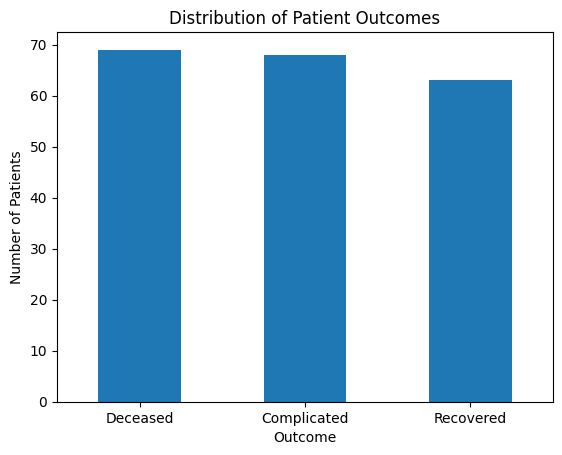

In [7]:
# Visualize outcome distribution
outcome_counts.plot(kind='bar')

plt.title('Distribution of Patient Outcomes')
plt.xlabel('Outcome')
plt.ylabel('Number of Patients')
plt.xticks(rotation=0)
plt.show()

 Feature Patterns Across Patient Outcomes

Numeric patient characteristics are compared across outcome groups to assess whether they contain useful predictive information.

In [8]:
numeric_features = [
    'Age',
    'TreatmentCost',
    'LengthOfStay',
    'Blood Pressure',
    'Blood Sugar',
    'Cholesterol',
    'Creatinine',
    'Hemoglobin',
    'Vitamin D'
]

outcome_summary = data.groupby('OutcomeName')[numeric_features].mean().round(2)

outcome_summary

,Age,TreatmentCost,LengthOfStay,Blood Pressure,Blood Sugar,Cholesterol,Creatinine,Hemoglobin,Vitamin D
OutcomeName,,,,,,,,,
Complicated,59.34,6507.53,22.91,220.16,162.90,197.78,162.57,174.43,196.45
Deceased,58.45,5975.90,32.83,148.48,149.68,165.20,148.86,189.06,157.00
Recovered,60.27,5811.63,31.89,144.01,225.64,153.81,176.81,165.79,165.64


In [9]:
lab_counts_by_outcome = data.groupby('OutcomeName')[
    ['Blood Pressure', 'Blood Sugar', 'Cholesterol',
     'Creatinine', 'Hemoglobin', 'Vitamin D']
].count()

lab_counts_by_outcome

,Blood Pressure,Blood Sugar,Cholesterol,Creatinine,Hemoglobin,Vitamin D
OutcomeName,,,,,,
Complicated,13,14,15,10,9,16
Deceased,10,10,10,8,7,10
Recovered,10,5,8,7,9,14


 6. Target Definition and Feature Selection

Patient outcomes are converted into a binary prediction target:

- **0 — Recovered**
- **1 — Adverse Outcome (Complicated or Deceased)**

The model uses demographic, diagnosis, utilization, treatment-cost, and available laboratory information. Missing laboratory measurements are handled during model preprocessing rather than being interpreted as zero.

In [10]:
# Create binary prediction target
data['AdverseOutcome'] = data['OutcomeName'].isin(
    ['Complicated', 'Deceased']
).astype(int)

# Create a feature indicating how many lab tests are available
lab_columns = [
    'Blood Pressure',
    'Blood Sugar',
    'Cholesterol',
    'Creatinine',
    'Hemoglobin',
    'Vitamin D'
]

data['LabTestsAvailable'] = data[lab_columns].notna().sum(axis=1)

print(data['AdverseOutcome'].value_counts())
print()
print(data['AdverseOutcome'].value_counts(normalize=True).round(3))

AdverseOutcome
1    137
0     63
Name: count, dtype: int64

AdverseOutcome
1    0.685
0    0.315
Name: proportion, dtype: float64


 7. Machine Learning Preprocessing

The dataset is divided into training and testing sets using stratified sampling to preserve the target distribution. Numeric missing values are imputed using the median, while categorical variables are one-hot encoded. Preprocessing is performed within a pipeline to prevent information leakage between training and test data.

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Numerical features
numeric_features = [
    'Age',
    'TreatmentCost',
    'LengthOfStay',
    'Blood Pressure',
    'Blood Sugar',
    'Cholesterol',
    'Creatinine',
    'Hemoglobin',
    'Vitamin D',
    'LabTestsAvailable'
]

# Categorical features
categorical_features = [
    'Gender',
    'DiagnosisName'
]

# Feature matrix and target
X = data[numeric_features + categorical_features]
y = data['AdverseOutcome']

# Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Numeric preprocessing
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical preprocessing
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training samples: 140
Testing samples: 60

Training target distribution:
AdverseOutcome
1    96
0    44
Name: count, dtype: int64

Testing target distribution:
AdverseOutcome
1    41
0    19
Name: count, dtype: int64


 8. Logistic Regression Model

A Logistic Regression classifier is trained as an interpretable baseline model using the complete preprocessing pipeline. Class balancing is applied to reduce bias toward the majority adverse-outcome class.

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_auc_score
)

# Create complete ML pipeline
logistic_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ))
])

# Train model
logistic_model.fit(X_train, y_train)

# Predictions
y_pred_log = logistic_model.predict(X_test)
y_prob_log = logistic_model.predict_proba(X_test)[:, 1]

# Evaluation
print("Logistic Regression - Model v2")
print("\nAccuracy:", round(accuracy_score(y_test, y_pred_log), 3))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_log), 3))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_log))

Logistic Regression - Model v2

Accuracy: 0.483
ROC-AUC: 0.448

Classification Report:
              precision    recall  f1-score   support

           0       0.27      0.37      0.31        19
           1       0.65      0.54      0.59        41

    accuracy                           0.48        60
   macro avg       0.46      0.45      0.45        60
weighted avg       0.53      0.48      0.50        60

Confusion Matrix:
[[ 7 12]
 [19 22]]


In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

logistic_unbalanced = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

logistic_unbalanced.fit(X_train, y_train)

y_pred_unbalanced = logistic_unbalanced.predict(X_test)
y_prob_unbalanced = logistic_unbalanced.predict_proba(X_test)[:, 1]

print("Logistic Regression - Without Class Weight")
print("Accuracy:", round(accuracy_score(y_test, y_pred_unbalanced), 3))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_unbalanced), 3))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_unbalanced))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_unbalanced))

Logistic Regression - Without Class Weight
Accuracy: 0.667
ROC-AUC: 0.458

Classification Report:
              precision    recall  f1-score   support

           0       0.44      0.21      0.29        19
           1       0.71      0.88      0.78        41

    accuracy                           0.67        60
   macro avg       0.58      0.54      0.53        60
weighted avg       0.62      0.67      0.63        60

Confusion Matrix:
[[ 4 15]
 [ 5 36]]


 9. Patient Risk Stratification

Because the available synthetic dataset showed limited predictive signal for final patient outcomes, a transparent rule-based risk stratification approach was developed using pre-outcome patient information.

The risk score uses age, diagnosis, and selected abnormal laboratory indicators. Final patient outcome is intentionally excluded to prevent data leakage.

> **Note:** This scoring framework is designed for demonstration and portfolio purposes and is not a validated clinical risk assessment tool.

In [14]:
# Initialize risk score
data['RiskScore'] = 0

# 1. Age risk
data.loc[data['Age'] > 65, 'RiskScore'] += 1

# 2. Diagnosis risk
high_risk_diagnoses = [
    'Heart Disease',
    'Stroke',
    'Cancer',
    'Kidney Disease',
    'Liver Disease',
    'COPD'
]

data.loc[
    data['DiagnosisName'].isin(high_risk_diagnoses),
    'RiskScore'
] += 1

# 3. Abnormal laboratory indicators
data.loc[data['Blood Sugar'] > 120, 'RiskScore'] += 1
data.loc[data['Cholesterol'] > 200, 'RiskScore'] += 1
data.loc[data['Hemoglobin'] < 13, 'RiskScore'] += 1

# Convert score into risk levels
data['RiskLevel'] = pd.cut(
    data['RiskScore'],
    bins=[-1, 0, 2, 5],
    labels=['Low', 'Moderate', 'High']
)

print("Risk Score Distribution:")
print(data['RiskScore'].value_counts().sort_index())

print("\nRisk Level Distribution:")
print(data['RiskLevel'].value_counts())

Risk Score Distribution:
RiskScore
0    45
1    88
2    54
3    12
4     1
Name: count, dtype: int64

Risk Level Distribution:
RiskLevel
Moderate    142
Low          45
High         13
Name: count, dtype: int64


 10. Risk Stratification Analysis

The distribution of patient risk levels was analyzed to understand the characteristics of each risk group and compare the project-defined risk categories with observed patient outcomes.

In [15]:
# Compare risk levels with actual patient outcomes
risk_outcome_table = pd.crosstab(
    data['RiskLevel'],
    data['OutcomeName'],
    margins=True
)

print("Risk Level vs Actual Outcome:")
print(risk_outcome_table)

# Percentage distribution of outcomes within each risk level
risk_outcome_percent = pd.crosstab(
    data['RiskLevel'],
    data['OutcomeName'],
    normalize='index'
) * 100

print("\nOutcome Percentage Within Each Risk Level:")
print(risk_outcome_percent.round(2))

Risk Level vs Actual Outcome:
OutcomeName  Complicated  Deceased  Recovered  All
RiskLevel                                         
Low                   17        15         13   45
Moderate              43        53         46  142
High                   8         1          4   13
All                   68        69         63  200

Outcome Percentage Within Each Risk Level:
OutcomeName  Complicated  Deceased  Recovered
RiskLevel                                    
Low                37.78     33.33      28.89
Moderate           30.28     37.32      32.39
High               61.54      7.69      30.77


 11. Risk Level Visualization

The distribution of patients across the project-defined risk categories is visualized below.

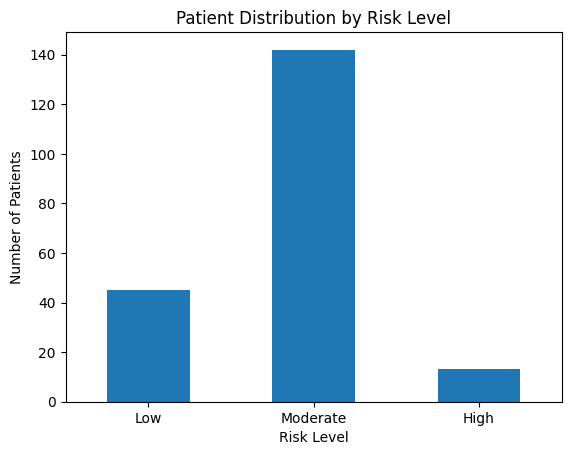

In [16]:
risk_counts = data['RiskLevel'].value_counts().reindex(
    ['Low', 'Moderate', 'High']
)

risk_counts.plot(kind='bar')

plt.title('Patient Distribution by Risk Level')
plt.xlabel('Risk Level')
plt.ylabel('Number of Patients')
plt.xticks(rotation=0)
plt.show()

 12. Risk Group Characteristics

Patient characteristics were summarized across risk levels to understand the demographic, utilization, and cost patterns associated with each risk category.

In [17]:
risk_summary = data.groupby(
    'RiskLevel',
    observed=False
)[['Age', 'TreatmentCost', 'LengthOfStay', 'RiskScore']].mean().round(2)

print("Average Patient Characteristics by Risk Level:")
risk_summary

Average Patient Characteristics by Risk Level:


,Age,TreatmentCost,LengthOfStay,RiskScore
RiskLevel,,,,
Low,47.73,6145.07,28.71,0.00
Moderate,61.13,6065.48,29.01,1.38
High,79.77,6396.62,32.38,3.08


 13. Risk Distribution by Diagnosis

Risk levels were compared across diagnosis groups to identify which conditions contain higher concentrations of moderate- and high-risk patients.

In [18]:
diagnosis_risk = pd.crosstab(
    data['DiagnosisName'],
    data['RiskLevel']
)

diagnosis_risk

RiskLevel,Low,Moderate,High
DiagnosisName,,,
Arthritis,10,6,1
Asthma,11,6,0
COPD,0,18,2
Cancer,0,17,1
Diabetes,8,9,0
Heart Disease,0,22,2
Hypertension,16,11,1
Kidney Disease,0,10,0
Liver Disease,0,23,3


In [19]:
risk_validation = data.groupby(
    'RiskLevel',
    observed=False
).agg(
    Patients=('PatientID', 'count'),
    AdverseOutcomes=('AdverseOutcome', 'sum'),
    AverageRiskScore=('RiskScore', 'mean')
)

risk_validation['AdverseOutcomeRate'] = (
    risk_validation['AdverseOutcomes'] /
    risk_validation['Patients'] * 100
).round(2)

risk_validation['AverageRiskScore'] = (
    risk_validation['AverageRiskScore'].round(2)
)

risk_validation

,Patients,AdverseOutcomes,AverageRiskScore,AdverseOutcomeRate
RiskLevel,,,,
Low,45,32,0.00,71.11
Moderate,142,96,1.38,67.61
High,13,9,3.08,69.23


 Risk Stratification Validation

The project-defined risk score successfully segmented patients into Low, Moderate, and High risk categories based on age, diagnosis, and selected laboratory indicators.

However, retrospective comparison with recorded patient outcomes showed similar adverse-outcome rates across all three groups:

- Low Risk: 71.11%
- Moderate Risk: 67.61%
- High Risk: 69.23%

Therefore, the risk categories should be interpreted as an illustrative stratification framework rather than a validated predictor of patient outcomes. This finding is consistent with the weak discrimination observed in the machine-learning experiments and suggests limited predictive signal in the synthetic dataset.

 14. Export Final Analytical Dataset

The cleaned and engineered patient-level dataset is exported for use in the interactive risk stratification application and dashboard.

In [20]:
final_data = data.copy()

final_data.to_csv(
    'healthcare_risk_final.csv',
    index=False
)

print("Final dataset exported successfully.")
print("Shape:", final_data.shape)

Final dataset exported successfully.
Shape: (200, 22)


In [21]:
%%writefile app.py

import streamlit as st
import pandas as pd

st.set_page_config(
    page_title="Healthcare Risk Stratification",
    page_icon="🏥",
    layout="wide"
)

st.title("🏥 Healthcare Risk Stratification")
st.write(
    "Interactive application for analyzing patient information "
    "and generating an illustrative risk classification."
)

st.info(
    "This application is developed for educational and portfolio purposes "
    "and is not a validated clinical decision-support tool."
)

Writing app.py


In [22]:
%%writefile -a app.py

st.header("Patient Risk Assessment")

age = st.number_input(
    "Age",
    min_value=18,
    max_value=100,
    value=50
)

gender = st.selectbox(
    "Gender",
    ["M", "F"]
)

diagnosis = st.selectbox(
    "Diagnosis",
    [
        "Arthritis",
        "Asthma",
        "COPD",
        "Cancer",
        "Diabetes",
        "Heart Disease",
        "Hypertension",
        "Kidney Disease",
        "Liver Disease",
        "Stroke"
    ]
)

st.subheader("Laboratory Information")

blood_sugar = st.number_input(
    "Blood Sugar",
    min_value=0.0,
    value=100.0
)

cholesterol = st.number_input(
    "Cholesterol",
    min_value=0.0,
    value=180.0
)

hemoglobin = st.number_input(
    "Hemoglobin",
    min_value=0.0,
    value=14.0
)

Appending to app.py


In [23]:
%%writefile -a app.py

# Risk calculation
high_risk_diagnoses = [
    "Heart Disease",
    "Stroke",
    "Cancer",
    "Kidney Disease",
    "Liver Disease",
    "COPD"
]

if st.button("Calculate Risk"):

    risk_score = 0
    risk_factors = []

    if age > 65:
        risk_score += 1
        risk_factors.append("Age above 65")

    if diagnosis in high_risk_diagnoses:
        risk_score += 1
        risk_factors.append("Selected diagnosis")

    if blood_sugar > 120:
        risk_score += 1
        risk_factors.append("Elevated blood sugar")

    if cholesterol > 200:
        risk_score += 1
        risk_factors.append("Elevated cholesterol")

    if hemoglobin < 13:
        risk_score += 1
        risk_factors.append("Low hemoglobin")

    # Assign risk category
    if risk_score == 0:
        risk_level = "Low"
    elif risk_score <= 2:
        risk_level = "Moderate"
    else:
        risk_level = "High"

    st.subheader("Risk Assessment Result")

    st.metric(
        label="Risk Score",
        value=f"{risk_score} / 5"
    )

    if risk_level == "Low":
        st.success("Risk Level: LOW")

    elif risk_level == "Moderate":
        st.warning("Risk Level: MODERATE")

    else:
        st.error("Risk Level: HIGH")

    if risk_factors:
        st.write("**Risk indicators identified:**")
        for factor in risk_factors:
            st.write(f"- {factor}")
    else:
        st.write("No risk indicators were identified by the project scoring rules.")

Appending to app.py


In [24]:
!pip install streamlit -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 40.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 77.8 MB/s eta 0:00:00


In [25]:
!python -m py_compile app.py
print("app.py is ready!")

app.py is ready!


In [26]:
!streamlit run app.py --server.port 8501 &>/content/logs.txt &

In [27]:
from google.colab import output
output.serve_kernel_port_as_window(8501)

Try `serve_kernel_port_as_iframe` instead. 


<IPython.core.display.Javascript object>

In [28]:
!cat /content/logs.txt



2026-10-01 17:25:46.470 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.106.159.207:8501

2026-10-01 17:26:52.190 Rejecting WebSocket connection with disallowed Origin or Host header: origin=https://8501-m-s-kkb-usw3b2-6w8d0c67l00u-b.us-west3-2.prod.colab.dev, host=m-s-kkb-usw3b2-6w8d0c67l00u.us-west3-b.c.codatalab-user-runtimes.internal:8007
2026-10-01 17:26:54.943 Rejecting WebSocket connection with disallowed Origin or Host header: origin=https://8501-m-s-kkb-usw3b2-6w8d0c67l00u-b.us-west3-2.prod.colab.dev, host=m-s-kkb-usw3b2-6w8d0c67l00u.us-west3-b.c.codatalab-user-runtimes.internal:8007
2026-10-01 17:26:57.493 Rejecting WebSocket connection with disallowed Origin or Host header: origin=https://8501-m-s-kkb-usw3b2-6w8d0c67l00u-b.us-west3-2.prod.colab.dev, host=m-s-kkb-usw3b2-6w8d0c67l00u.us-west3-b.c.codatalab-user-runtimes.internal:8007


In [29]:
!pkill -f streamlit

In [30]:
!streamlit run app.py \
    --server.port 8501 \
    --server.enableCORS false \
    --server.enableXsrfProtection false \
    &>/content/logs.txt &

In [31]:
from google.colab import output
output.serve_kernel_port_as_window(8501)

Try `serve_kernel_port_as_iframe` instead. 


<IPython.core.display.Javascript object>

In [32]:
%%writefile app.py

import streamlit as st
import pandas as pd

# --------------------------------------------------
# PAGE CONFIGURATION
# --------------------------------------------------

st.set_page_config(
    page_title="Healthcare Risk Stratification",
    page_icon="🏥",
    layout="wide"
)

# --------------------------------------------------
# HEADER
# --------------------------------------------------

st.title("🏥 Healthcare Risk Stratification")
st.caption(
    "Patient-level risk assessment using demographic, diagnostic, "
    "and laboratory indicators."
)

st.info(
    "This application is developed for educational and portfolio purposes. "
    "The risk framework is illustrative and is not a validated clinical "
    "decision-support tool."
)

st.divider()

# --------------------------------------------------
# PATIENT INFORMATION
# --------------------------------------------------

st.subheader("👤 Patient Information")

col1, col2 = st.columns(2)

with col1:
    age = st.number_input(
        "Age",
        min_value=18,
        max_value=100,
        value=50
    )

with col2:
    gender = st.selectbox(
        "Gender",
        ["M", "F"]
    )

diagnosis = st.selectbox(
    "Primary Diagnosis",
    [
        "Arthritis",
        "Asthma",
        "COPD",
        "Cancer",
        "Diabetes",
        "Heart Disease",
        "Hypertension",
        "Kidney Disease",
        "Liver Disease",
        "Stroke"
    ]
)

# --------------------------------------------------
# LAB INFORMATION
# --------------------------------------------------

st.subheader("🧪 Laboratory Information")

lab1, lab2, lab3 = st.columns(3)

with lab1:
    blood_sugar = st.number_input(
        "Blood Sugar",
        min_value=0.0,
        value=100.0,
        step=1.0
    )

with lab2:
    cholesterol = st.number_input(
        "Cholesterol",
        min_value=0.0,
        value=180.0,
        step=1.0
    )

with lab3:
    hemoglobin = st.number_input(
        "Hemoglobin",
        min_value=0.0,
        value=14.0,
        step=0.1
    )

st.divider()

# --------------------------------------------------
# RISK CALCULATION
# --------------------------------------------------

high_risk_diagnoses = [
    "Heart Disease",
    "Stroke",
    "Cancer",
    "Kidney Disease",
    "Liver Disease",
    "COPD"
]

if st.button(
    "Assess Patient Risk",
    type="primary",
    use_container_width=True
):

    risk_score = 0
    risk_factors = []

    if age > 65:
        risk_score += 1
        risk_factors.append("Age above 65")

    if diagnosis in high_risk_diagnoses:
        risk_score += 1
        risk_factors.append("Selected diagnosis")

    if blood_sugar > 120:
        risk_score += 1
        risk_factors.append("Elevated blood sugar")

    if cholesterol > 200:
        risk_score += 1
        risk_factors.append("Elevated cholesterol")

    if hemoglobin < 13:
        risk_score += 1
        risk_factors.append("Low hemoglobin")

    if risk_score == 0:
        risk_level = "LOW"
    elif risk_score <= 2:
        risk_level = "MODERATE"
    else:
        risk_level = "HIGH"

    # --------------------------------------------------
    # RESULTS
    # --------------------------------------------------

    st.subheader("📋 Risk Assessment Result")

    result1, result2, result3 = st.columns(3)

    with result1:
        st.metric(
            "Risk Score",
            f"{risk_score} / 5"
        )

    with result2:
        st.metric(
            "Risk Level",
            risk_level
        )

    with result3:
        st.metric(
            "Risk Indicators",
            len(risk_factors)
        )

    if risk_level == "LOW":
        st.success("Low project-defined risk level.")

    elif risk_level == "MODERATE":
        st.warning("Moderate project-defined risk level.")

    else:
        st.error("High project-defined risk level.")

    st.markdown("#### Contributing Risk Indicators")

    if risk_factors:
        for factor in risk_factors:
            st.write(f"• {factor}")
    else:
        st.write(
            "No risk indicators were identified using "
            "the project scoring framework."
        )

    with st.expander("How is the risk score calculated?"):
        st.write("""
        One point is assigned for each project-defined indicator:

        - Age above 65
        - Selected higher-risk diagnosis
        - Blood Sugar above 120
        - Cholesterol above 200
        - Hemoglobin below 13

        **Risk categories**

        - 0 points → Low Risk
        - 1–2 points → Moderate Risk
        - 3–5 points → High Risk
        """)

st.divider()

st.caption(
    "Healthcare Analytics Portfolio Project | "
    "SQL • Excel • Python • Risk Stratification • Streamlit"
)

Overwriting app.py


In [33]:
import pandas as pd

test_data = pd.read_csv("healthcare_risk_final.csv")

print("Dataset loaded successfully!")
print("Shape:", test_data.shape)

print("\nRisk Levels:")
print(test_data["RiskLevel"].value_counts())

Dataset loaded successfully!
Shape: (200, 22)

Risk Levels:
RiskLevel
Moderate    142
Low          45
High         13
Name: count, dtype: int64


In [34]:
%%writefile app.py

import streamlit as st
import pandas as pd

# --------------------------------------------------
# PAGE CONFIGURATION
# --------------------------------------------------

st.set_page_config(
    page_title="Healthcare Risk Analytics",
    page_icon="🏥",
    layout="wide"
)

# --------------------------------------------------
# LOAD DATA
# --------------------------------------------------

@st.cache_data
def load_data():
    return pd.read_csv("healthcare_risk_final.csv")

data = load_data()

# --------------------------------------------------
# HEADER
# --------------------------------------------------

st.title("🏥 Healthcare Risk Analytics")
st.caption(
    "Interactive patient risk stratification and healthcare analytics dashboard."
)

st.info(
    "This application is developed for educational and portfolio purposes. "
    "The risk framework is illustrative and is not a validated clinical "
    "decision-support tool."
)

# --------------------------------------------------
# TABS
# --------------------------------------------------

risk_tab, analytics_tab = st.tabs([
    "🩺 Risk Assessment",
    "📊 Patient Analytics"
])

# ==================================================
# TAB 1 — RISK ASSESSMENT
# ==================================================

with risk_tab:

    st.subheader("Patient Information")

    col1, col2 = st.columns(2)

    with col1:
        age = st.number_input(
            "Age",
            min_value=18,
            max_value=100,
            value=50
        )

    with col2:
        diagnosis = st.selectbox(
            "Primary Diagnosis",
            [
                "Arthritis",
                "Asthma",
                "COPD",
                "Cancer",
                "Diabetes",
                "Heart Disease",
                "Hypertension",
                "Kidney Disease",
                "Liver Disease",
                "Stroke"
            ]
        )

    st.subheader("🧪 Laboratory Information")

    lab1, lab2, lab3 = st.columns(3)

    with lab1:
        blood_sugar = st.number_input(
            "Blood Sugar",
            min_value=0.0,
            value=100.0,
            step=1.0
        )

    with lab2:
        cholesterol = st.number_input(
            "Cholesterol",
            min_value=0.0,
            value=180.0,
            step=1.0
        )

    with lab3:
        hemoglobin = st.number_input(
            "Hemoglobin",
            min_value=0.0,
            value=14.0,
            step=0.1
        )

    st.divider()

    high_risk_diagnoses = [
        "Heart Disease",
        "Stroke",
        "Cancer",
        "Kidney Disease",
        "Liver Disease",
        "COPD"
    ]

    if st.button(
        "Assess Patient Risk",
        type="primary",
        use_container_width=True
    ):

        risk_score = 0
        risk_factors = []

        if age > 65:
            risk_score += 1
            risk_factors.append("Age above 65")

        if diagnosis in high_risk_diagnoses:
            risk_score += 1
            risk_factors.append("Selected diagnosis")

        if blood_sugar > 120:
            risk_score += 1
            risk_factors.append("Elevated blood sugar")

        if cholesterol > 200:
            risk_score += 1
            risk_factors.append("Elevated cholesterol")

        if hemoglobin < 13:
            risk_score += 1
            risk_factors.append("Low hemoglobin")

        if risk_score == 0:
            risk_level = "LOW"
        elif risk_score <= 2:
            risk_level = "MODERATE"
        else:
            risk_level = "HIGH"

        st.subheader("📋 Risk Assessment Result")

        result1, result2, result3 = st.columns(3)

        with result1:
            st.metric("Risk Score", f"{risk_score} / 5")

        with result2:
            st.metric("Risk Level", risk_level)

        with result3:
            st.metric("Risk Indicators", len(risk_factors))

        if risk_level == "LOW":
            st.success("Low project-defined risk level.")
        elif risk_level == "MODERATE":
            st.warning("Moderate project-defined risk level.")
        else:
            st.error("High project-defined risk level.")

        st.markdown("#### Contributing Risk Indicators")

        if risk_factors:
            for factor in risk_factors:
                st.write(f"• {factor}")
        else:
            st.write(
                "No risk indicators were identified using "
                "the project scoring framework."
            )

        with st.expander("How is the risk score calculated?"):
            st.markdown("""
            One point is assigned for each project-defined indicator:

            - Age above 65
            - Selected higher-risk diagnosis
            - Blood Sugar above 120
            - Cholesterol above 200
            - Hemoglobin below 13

            **Risk categories**

            - 0 points → Low Risk
            - 1–2 points → Moderate Risk
            - 3–5 points → High Risk
            """)

# ==================================================
# TAB 2 — PATIENT ANALYTICS
# ==================================================

with analytics_tab:

    st.subheader("Patient Population Overview")

    total_patients = len(data)
    low_risk = (data["RiskLevel"] == "Low").sum()
    moderate_risk = (data["RiskLevel"] == "Moderate").sum()
    high_risk = (data["RiskLevel"] == "High").sum()

    m1, m2, m3, m4 = st.columns(4)

    with m1:
        st.metric("Total Patients", total_patients)

    with m2:
        st.metric("Low Risk", low_risk)

    with m3:
        st.metric("Moderate Risk", moderate_risk)

    with m4:
        st.metric("High Risk", high_risk)

    st.divider()

    # Risk distribution
    st.subheader("Risk Level Distribution")

    risk_distribution = (
        data["RiskLevel"]
        .value_counts()
        .reindex(["Low", "Moderate", "High"])
    )

    st.bar_chart(risk_distribution)

    st.divider()

    # Diagnosis distribution
    st.subheader("Patients by Diagnosis")

    diagnosis_distribution = (
        data["DiagnosisName"]
        .value_counts()
        .sort_values(ascending=False)
    )

    st.bar_chart(diagnosis_distribution)

    st.divider()

    # Additional metrics
    st.subheader("Healthcare Utilization")

    c1, c2 = st.columns(2)

    with c1:
        st.metric(
            "Average Treatment Cost",
            f"{data['TreatmentCost'].mean():,.2f}"
        )

    with c2:
        st.metric(
            "Average Length of Stay",
            f"{data['LengthOfStay'].mean():.1f} days"
        )

# --------------------------------------------------
# FOOTER
# --------------------------------------------------

st.divider()

st.caption(
    "Healthcare Analytics Portfolio Project | "
    "SQL • Excel • Python • Risk Stratification • Streamlit"
)

Overwriting app.py


In [35]:
from pathlib import Path

path = Path("app.py")
code = path.read_text()

old_section = '''    st.divider()

    # Risk distribution
    st.subheader("Risk Level Distribution")

    risk_distribution = (
        data["RiskLevel"]
        .value_counts()
        .reindex(["Low", "Moderate", "High"])
    )

    st.bar_chart(risk_distribution)

    st.divider()

    # Diagnosis distribution
    st.subheader("Patients by Diagnosis")

    diagnosis_distribution = (
        data["DiagnosisName"]
        .value_counts()
        .sort_values(ascending=False)
    )

    st.bar_chart(diagnosis_distribution)
'''

new_section = '''    st.divider()

    # Charts displayed side-by-side
    chart1, chart2 = st.columns(2)

    with chart1:
        st.subheader("Risk Level Distribution")

        risk_distribution = (
            data["RiskLevel"]
            .value_counts()
            .reindex(["Low", "Moderate", "High"])
        )

        st.bar_chart(
            risk_distribution,
            height=350
        )

    with chart2:
        st.subheader("Patients by Diagnosis")

        diagnosis_distribution = (
            data["DiagnosisName"]
            .value_counts()
            .sort_values(ascending=False)
        )

        st.bar_chart(
            diagnosis_distribution,
            height=350
        )
'''

if old_section in code:
    code = code.replace(old_section, new_section)
    path.write_text(code)
    print("✅ Charts updated successfully!")
else:
    print("❌ Section not found — app.py was not changed.")

✅ Charts updated successfully!


In [36]:
%%writefile requirements.txt
streamlit
pandas

Writing requirements.txt
